In [2]:
import tensorflow as tf
import collections
import numpy as np
from tensorflow.keras import layers, Model



2025-10-08 12:31:14.840464: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def build_realtime_denoiser(window_size=10):
    inp = layers.Input(shape=(window_size, 1))

    # Causal Conv1D (padding='causal' ensures only past context)
    x = layers.Conv1D(16, kernel_size=3, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(8, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.Conv1D(1, kernel_size=1, padding='valid', activation='linear')(x)

    # Output only the last timestep (current sample)
    out = layers.Lambda(lambda z: z[:, -1, :])(x)
    return Model(inp, out)

model = build_realtime_denoiser(window_size=10)
model.compile(optimizer='adam', loss='mse')

W0000 00:00:1759919477.366294  244293 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
def generate_data(num_samples=1000, noise_factor=0.5):
    np.random.seed(42)
    t = np.linspace(0, 1, num_samples, dtype=np.float32)
    s = np.sin(2 * np.pi * t,dtype=np.float32)  # Clean signal
    n = noise_factor * np.random.normal(size=num_samples)  # Noise
    x = s + n  # Noisy signal
    x.astype(dtype=np.float32)
    s.astype(dtype=np.float32)
    return x, s


def create_seq(x:np.array, seq_len=10, n_samples=1000):
    # seq = np.zeros(shape=(seq_len, n_samples//seq_len))
    new_x = []
    seq = []
    for i in range(seq_len, n_samples):
        seq.append(x[i-seq_len:i])
    seq = np.array(seq)
    new_x.append(seq)
    return np.array(new_x)
        

In [5]:
X, y = generate_data()
x_test, y_test = generate_data()

In [6]:
X.shape

(1000,)

In [7]:
X = create_seq(X)
X = np.squeeze(X)

x_test_inf = create_seq(x_test)
x_test_inf = np.squeeze(x_test_inf)

In [8]:
X.shape

(990, 10)

In [9]:
model.fit(X, y, epochs=20, batch_size=64, validation_split=0.1)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5663 - val_loss: 0.1706
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3838 - val_loss: 0.1215
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2374 - val_loss: 0.0690
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1059 - val_loss: 0.0503
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0653 - val_loss: 0.0620
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0602 - val_loss: 0.0571
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0542 - val_loss: 0.0544
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0507 - val_loss: 0.0573
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0485 - val_loss: 0.0583
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0464 - val_loss: 0.0587
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0450 - val_loss: 0.0603
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0436 - val_l

In [10]:
print(x_test.shape, y_test.shape)

(1000,) (1000,)


In [ ]:
y_pred = []
for arr in x_test_inf:
    seq = np.array(arr)
    seq = np.expand_dims(seq, axis=0)
    val_pred = model.predict(seq)
    y_pred.append(val_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

In [31]:
pred = np.array(y_pred)

In [38]:
pred.shape

(990,)

In [ ]:
pred = np.squeeze(pred, axis = 1)
pred = np.squeeze(pred, axis = 1)

In [12]:
x_test_inf.shape

(990, 10)

In [41]:
y_pred = model.predict(x_test_inf, verbose=0)

In [27]:
y_pred.shape

(1, 1)

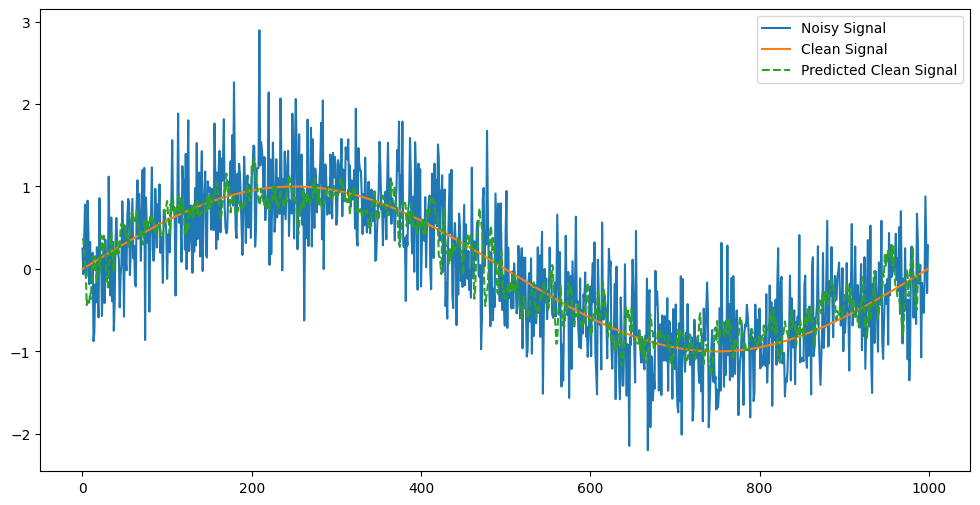

In [ ]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
# plt.savefig(f'results/{model_name}.png')

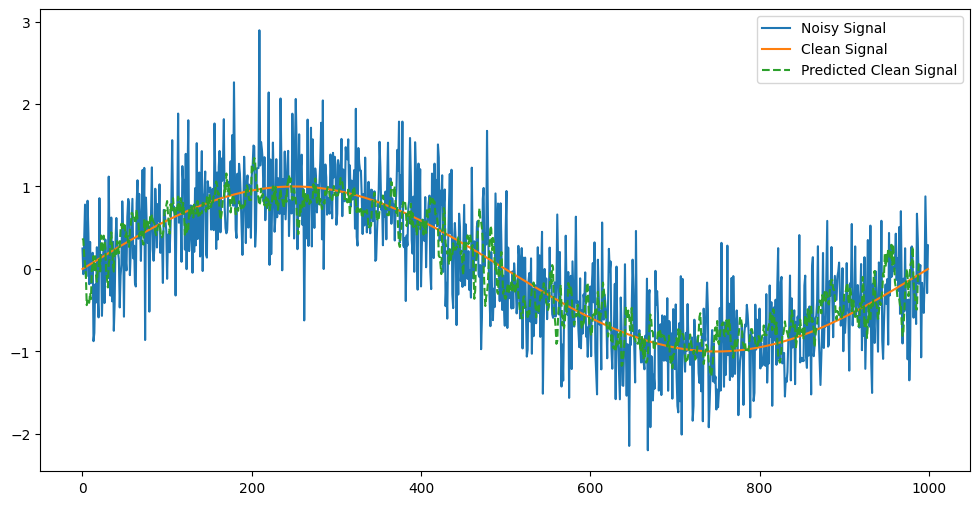

In [42]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(y_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
# plt.savefig(f'results/{model_name}.png')

In [43]:
model_name = "best_sequence_model"

In [44]:
model.save(f'checkpoints/{model_name}.keras')